# Tech Test - Klasifikasi Pengiriman Tepat Waktu

Notebook ini dibuat untuk menyelesaikan studi kasus prediksi apakah sebuah pesanan akan tiba tepat waktu berdasarkan data pelanggan dan produk.  
Tahapan yang akan dilakukan mencakup:
- Exploratory Data Analysis (EDA)
- Preprocessing
- Modeling
- Evaluasi
- Submission


In [1]:
# Import Library
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Pada tahap ini kita mengimpor semua library yang diperlukan untuk manipulasi data, visualisasi, dan pembuatan model.



## 2. Load Dataset

Memuat dataset train dan test yang sudah disediakan. Dataset train digunakan untuk membangun model, sedangkan dataset test digunakan untuk menguji hasil prediksi akhir.


In [2]:
# Load data
from google.colab import drive
drive.mount('/content/drive')
df_train = pd.read_csv('/content/drive/MyDrive/Rekrutasi_MBC/Technical_Test/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Rekrutasi_MBC/Technical_Test/test.csv')
#lokasi file dapat berubah tergantung lokasi kamu menyimpan

Mounted at /content/drive


## 3. Exploratory Data Analysis (EDA)

Melakukan eksplorasi awal untuk memahami karakteristik data, termasuk:
- distribusi target
- missing value
- ringkasan statistik


In [3]:
df_train.head()
# menampilkan 5 baris pertama

,id,blok_gudang,mode_pengiriman,panggilan_layanan_pelanggan,rating_pelanggan,harga_produk,pembelian_sebelumnya,kepentingan_produk,jenis_kelamin,diskon_ditawarkan,berat_dalam_gram,pengiriman_tepat_waktu
0,1,C,kapal,3,5,180.0,4,sedang,Perempuan,59,1481.0,1
1,2,C,darat,3,4,256.0,2,sedang,Laki-laki,55,2247.0,1
2,3,F,kapal,6,2,293.0,5,sedang,Perempuan,4,1281.0,0
3,4,F,kapal,7,5,243.0,5,sedang,Laki-laki,28,1100.0,1
4,5,A,kapal,2,5,139.0,3,NaN,Perempuan,27,1233.0,1


In [4]:
df_test.head()
## menampilkan 5 baris pertama

,id,blok_gudang,mode_pengiriman,panggilan_layanan_pelanggan,rating_pelanggan,harga_produk,pembelian_sebelumnya,kepentingan_produk,jenis_kelamin,diskon_ditawarkan,berat_dalam_gram
0,7561,D,pesawat,7,1,291.0,4,rendah,Laki-laki,2,1216.0
1,7562,C,darat,3,4,142.0,4,sedang,Laki-laki,5,4429.0
2,7563,B,kapal,4,1,188.0,2,rendah,Laki-laki,6,5894.0
3,7564,C,kapal,4,5,141.0,2,rendah,Laki-laki,1,4395.0
4,7565,B,kapal,6,4,309.0,4,rendah,Laki-laki,9,1771.0


In [5]:
df_train.info()
# melihat banyak datadari suato kolom, apakah ada null, dan jenis tipe datanya

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7551 entries, 0 to 7550
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           7551 non-null   int64  
 1   blok_gudang                  7551 non-null   object 
 2   mode_pengiriman              7551 non-null   object 
 3   panggilan_layanan_pelanggan  7551 non-null   int64  
 4   rating_pelanggan             7551 non-null   int64  
 5   harga_produk                 7484 non-null   float64
 6   pembelian_sebelumnya         7551 non-null   int64  
 7   kepentingan_produk           7445 non-null   object 
 8   jenis_kelamin                7551 non-null   object 
 9   diskon_ditawarkan            7551 non-null   int64  
 10  berat_dalam_gram             7448 non-null   float64
 11  pengiriman_tepat_waktu       7551 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 708.0+ KB


In [6]:
df_test.info()
# melihat banyak datadari suato kolom, apakah ada null, dan jenis tipe datanya

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           2200 non-null   int64  
 1   blok_gudang                  2200 non-null   object 
 2   mode_pengiriman              2200 non-null   object 
 3   panggilan_layanan_pelanggan  2200 non-null   int64  
 4   rating_pelanggan             2200 non-null   int64  
 5   harga_produk                 2176 non-null   float64
 6   pembelian_sebelumnya         2200 non-null   int64  
 7   kepentingan_produk           2171 non-null   object 
 8   jenis_kelamin                2200 non-null   object 
 9   diskon_ditawarkan            2200 non-null   int64  
 10  berat_dalam_gram             2176 non-null   float64
dtypes: float64(2), int64(5), object(4)
memory usage: 189.2+ KB


In [7]:
# melakukan pengecekan terhadap missing values di data train
missing = df_train.isnull().sum()
print("null di train:\n\n",missing[missing > 0])  # hanya tampilkan yang missing

missing_test = df_test.isnull().sum()
print("\nnull di test:\n\n",missing_test[missing_test > 0])

null di train:

 harga_produk           67
kepentingan_produk    106
berat_dalam_gram      103
dtype: int64

null di test:

 harga_produk          24
kepentingan_produk    29
berat_dalam_gram      24
dtype: int64


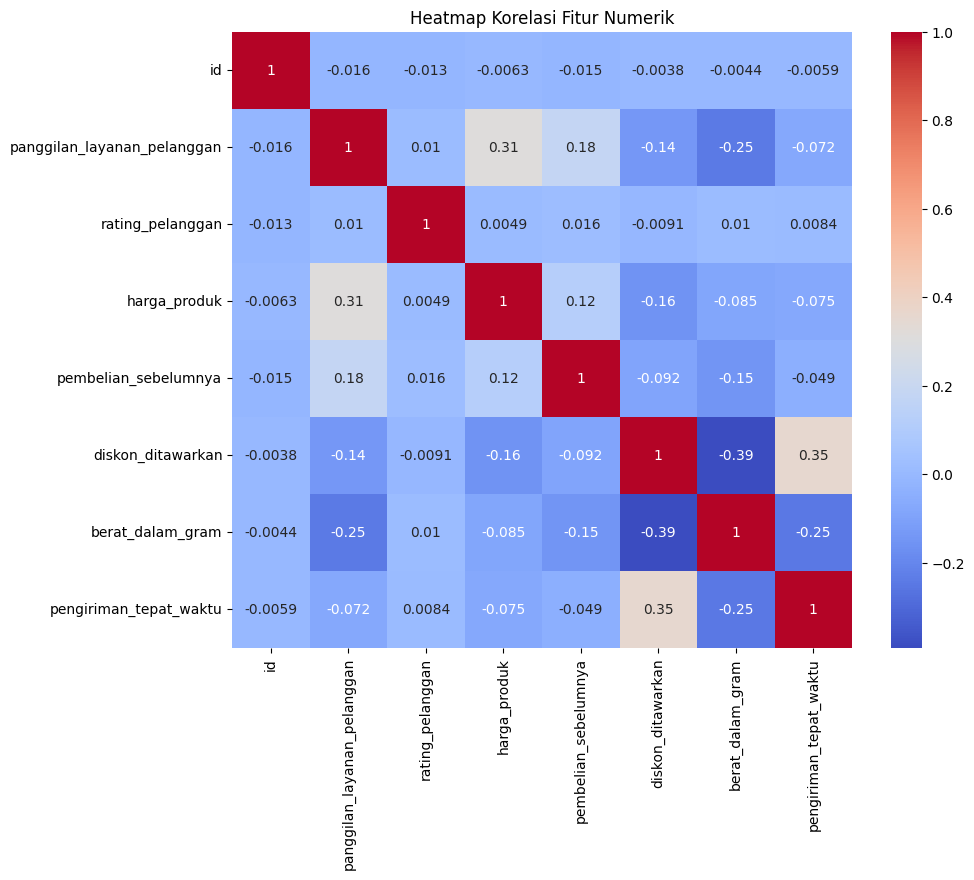

In [8]:
# ambil hanya kolom numerik
corr = df_train.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()



=== Analisis blok_gudang ===

Proporsi target per kategori:

pengiriman_tepat_waktu         0         1
blok_gudang                               
A                       0.315956  0.684044
B                       0.292035  0.707965
C                       0.315623  0.684377
D                       0.312399  0.687601
F                       0.302481  0.697519

Chi-square: 2.6401, p-value: 0.6197
→ Tidak signifikan (p >= 0.05)


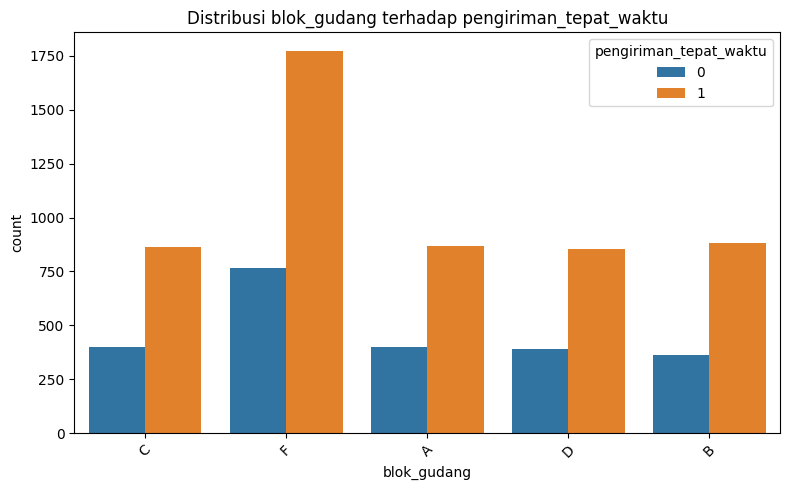


=== Analisis mode_pengiriman ===

Proporsi target per kategori:

pengiriman_tepat_waktu         0         1
mode_pengiriman                           
darat                   0.305695  0.694305
kapal                   0.310748  0.689252
pesawat                 0.291564  0.708436

Chi-square: 1.7157, p-value: 0.4241
→ Tidak signifikan (p >= 0.05)


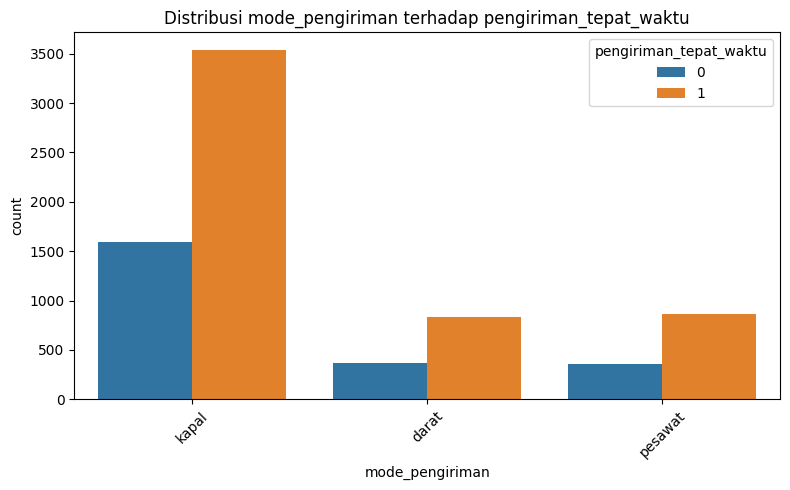


=== Analisis kepentingan_produk ===

Proporsi target per kategori:

pengiriman_tepat_waktu         0         1
kepentingan_produk                        
rendah                  0.311080  0.688920
sedang                  0.312382  0.687618
tinggi                  0.248086  0.751914

Chi-square: 11.3597, p-value: 0.0034
→ Hubungan signifikan dengan target (p < 0.05)


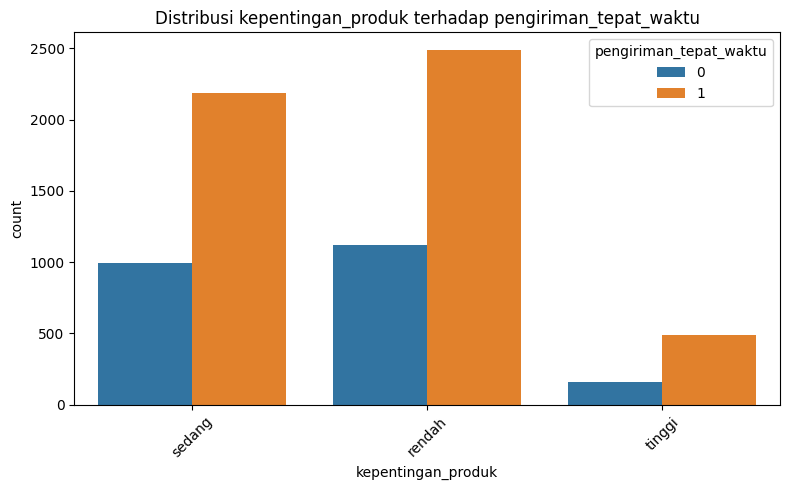


=== Analisis jenis_kelamin ===

Proporsi target per kategori:

pengiriman_tepat_waktu         0         1
jenis_kelamin                             
Laki-laki               0.305475  0.694525
Perempuan               0.308223  0.691777

Chi-square: 0.0547, p-value: 0.8150
→ Tidak signifikan (p >= 0.05)


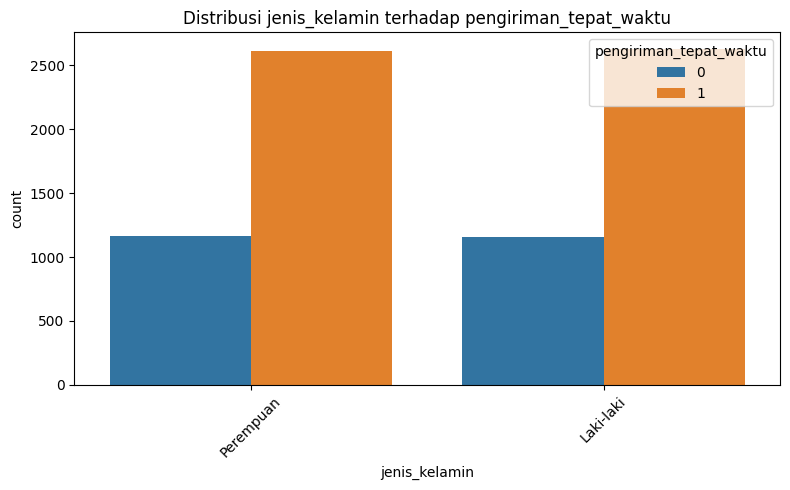

In [9]:
# daftar kolom kategorikal
categorical_cols = [
    'blok_gudang',
    'mode_pengiriman',
    'kepentingan_produk',
    'jenis_kelamin'
]

# loop tiap kolom
for col in categorical_cols:
    print(f"\n=== Analisis {col} ===\n")

    # 1. Crosstab
    ct = pd.crosstab(df_train[col], df_train['pengiriman_tepat_waktu'], normalize='index')
    print("Proporsi target per kategori:\n")
    print(ct)

    # 2. Chi-square
    chi_table = pd.crosstab(df_train[col], df_train['pengiriman_tepat_waktu'])
    chi2, p, dof, expected = chi2_contingency(chi_table)
    print(f"\nChi-square: {chi2:.4f}, p-value: {p:.4f}")
    if p < 0.05:
        print("→ Hubungan signifikan dengan target (p < 0.05)")
    else:
        print("→ Tidak signifikan (p >= 0.05)")

    # 3. Barplot visualisasi
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, hue='pengiriman_tepat_waktu', data=df_train)
    plt.title(f"Distribusi {col} terhadap pengiriman_tepat_waktu")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


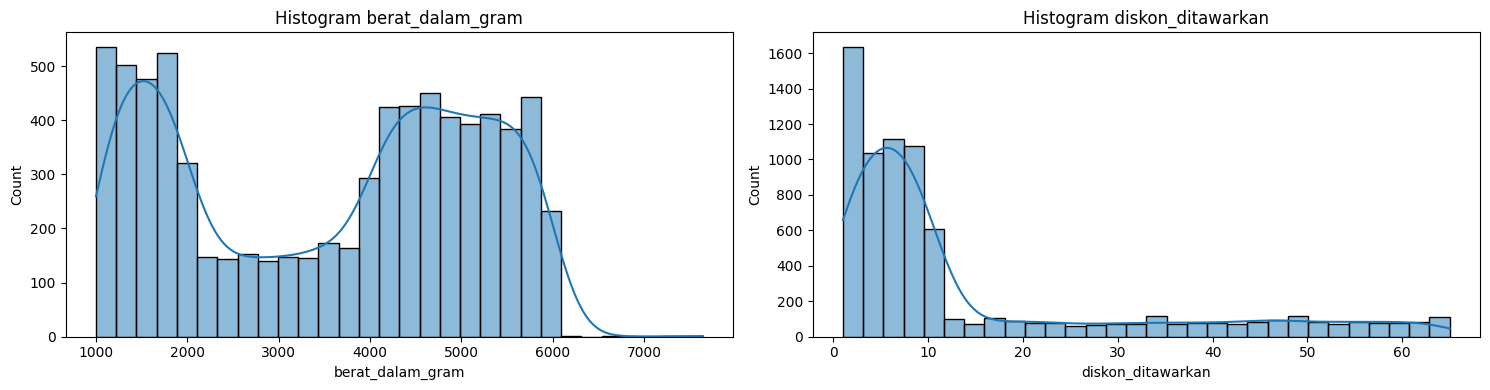

In [10]:
# pilih kolom numerik
numeric_cols = ['berat_dalam_gram', 'diskon_ditawarkan']

# layout
plt.figure(figsize=(15,4))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i+1)
    sns.histplot(df_train[col].dropna(), bins=30, kde=True)
    plt.title(f"Histogram {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


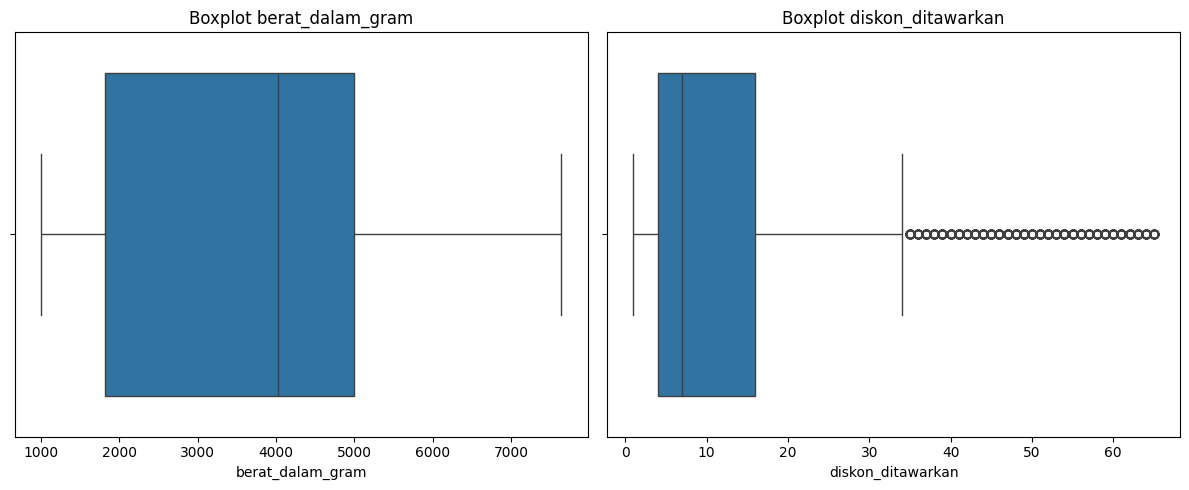

In [11]:
numeric_cols = ['berat_dalam_gram', 'diskon_ditawarkan']

plt.figure(figsize=(12,5))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 2, i+1)
    sns.boxplot(x=df_train[col])
    plt.title(f"Boxplot {col}")

plt.tight_layout()
plt.show()


## 4. Preprocessing Data

Tahap ini mencakup:
- memilih fitur yang relevan
- menangani missing value
- encoding variabel kategorikal


In [12]:

# Pilih fitur relevan atau membuat dataframe hanya dengan kolom penting
df_simplified = df_train[['berat_dalam_gram', 'diskon_ditawarkan', 'kepentingan_produk', 'pengiriman_tepat_waktu']].copy()


In [13]:
df_simplified.info()
#  Cek struktur dan tipe data dataframe hasil simplifikasi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7551 entries, 0 to 7550
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   berat_dalam_gram        7448 non-null   float64
 1   diskon_ditawarkan       7551 non-null   int64  
 2   kepentingan_produk      7445 non-null   object 
 3   pengiriman_tepat_waktu  7551 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 236.1+ KB


In [14]:
print("Jumlah nilai kosong di df_simplified:")
print(df_simplified.isnull().sum())

Jumlah nilai kosong di df_simplified:
berat_dalam_gram          103
diskon_ditawarkan           0
kepentingan_produk        106
pengiriman_tepat_waktu      0
dtype: int64


In [15]:
for col in ['kepentingan_produk']:
    print(f"\n{col} unique values:\n", df_simplified[col].value_counts(dropna=False))

# Mengecek kategori unik pada kepentingan_produk


kepentingan_produk unique values:
 kepentingan_produk
rendah    3610
sedang    3182
tinggi     653
NaN        106
Name: count, dtype: int64


In [16]:
# Imputasi Missing

#imputasi numerik
median = df_simplified['berat_dalam_gram'].median()
df_simplified['berat_dalam_gram'] = df_simplified['berat_dalam_gram'].fillna(median)


# kepentingan_produk
df_simplified['kepentingan_produk'] = df_simplified['kepentingan_produk'].fillna('rendah')

# cek hasil imputasi
print("\nMissing values (train) setelah imputasi:")
print(df_simplified.isnull().sum())



Missing values (train) setelah imputasi:
berat_dalam_gram          0
diskon_ditawarkan         0
kepentingan_produk        0
pengiriman_tepat_waktu    0
dtype: int64


In [17]:
# Encoding
kep_map = {"rendah":1, "sedang":2, "tinggi":3}
df_simplified['kepentingan_produk'] = df_simplified['kepentingan_produk'].map(kep_map)

print("\nUnique values kepentingan_produk setelah encoding:")
print(df_simplified['kepentingan_produk'].value_counts())



Unique values kepentingan_produk setelah encoding:
kepentingan_produk
1    3716
2    3182
3     653
Name: count, dtype: int64


## 5. Analisis Korelasi

Melihat hubungan antar fitur menggunakan matriks korelasi dan heatmap.


Text(0.5, 1.0, 'Heatmap Korelasi df_simplified')

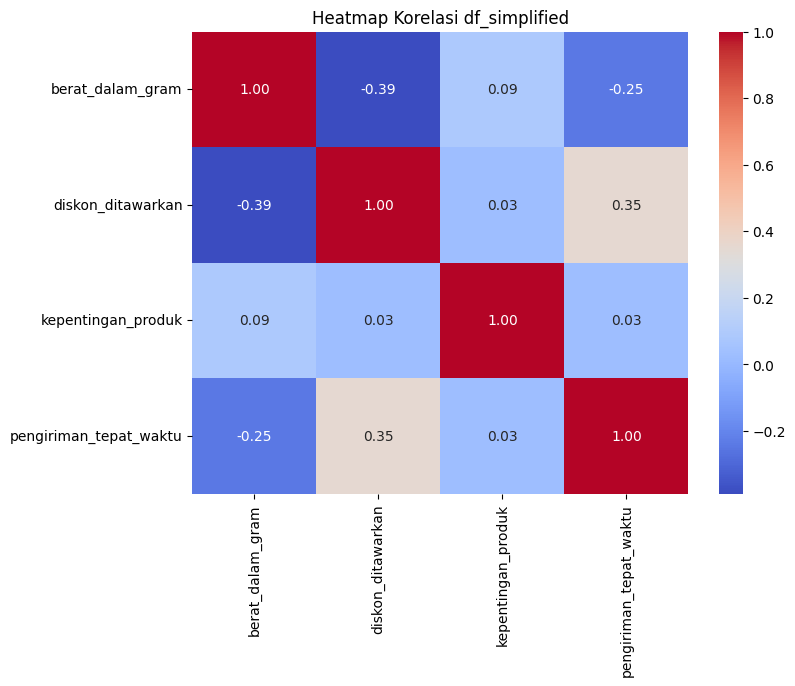

In [18]:
# korelasi matriks
corr = df_simplified.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi df_simplified")

## 6. Modeling

Membangun model Random Forest dengan GridSearchCV untuk mendapatkan parameter terbaik.  
Data akan dipisah menjadi training dan validation untuk menghindari overfitting.

In [19]:
# Split Train/Validation
X = df_simplified[['berat_dalam_gram', 'diskon_ditawarkan', 'kepentingan_produk']]
y = df_simplified['pengiriman_tepat_waktu']

#train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")

Train shape: (6040, 3), Validation shape: (1511, 3)


In [20]:
# Training random forest

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 7. Evaluasi Model

Mengukur kinerja model di data validasi menggunakan confusion matrix dan classification report.


Recall TRAINING: 0.9921
Recall VALIDATION: 0.7479


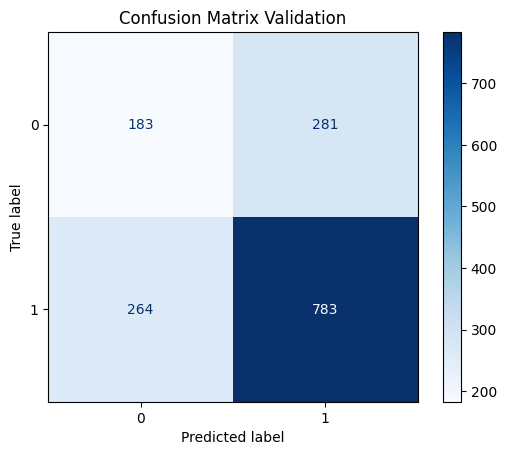

In [21]:
# evaluasi

# TRAIN
y_train_pred = rf_model.predict(X_train)
recall_train = recall_score(y_train, y_train_pred)
print(f"\nRecall TRAINING: {recall_train:.4f}")

# validation
y_val_pred = rf_model.predict(X_val)
recall_val = recall_score(y_val, y_val_pred)
print(f"Recall VALIDATION: {recall_val:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix Validation")
plt.show()

In [22]:
# 1. Definisikan parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [23]:
# RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,           # jumlah kombinasi random dicoba
    scoring='recall',    # fokus recall
    cv=5,                # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, scoring='recall', verbose=2)

In [24]:
# Hasil tuning
print(f"\nBest Parameters: {search.best_params_}")
print(f"Best Cross-Validation Recall: {search.best_score_:.4f}")


Best Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
Best Cross-Validation Recall: 0.9950



Recall VALIDATION after tuning: 0.9990


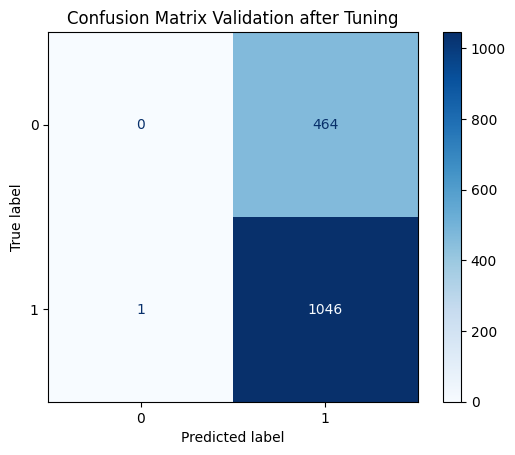

In [25]:
# Evaluasi ulang dengan model terbaik
best_rf = search.best_estimator_

# evaluasi di validation
y_val_pred = best_rf.predict(X_val)
recall_val = recall_score(y_val, y_val_pred)
print(f"\nRecall VALIDATION after tuning: {recall_val:.4f}")

# confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix Validation after Tuning")
plt.show()


## 8. Prediksi pada Data Test

Melakukan prediksi menggunakan model terbaik yang telah dilatih, dan memastikan proses preprocessing sama seperti di train.


In [26]:
# prediksi data test

# Ambil kolom
X_test = df_test[['berat_dalam_gram', 'diskon_ditawarkan', 'kepentingan_produk']].copy()

# Cek missing sebelum imputasi
print("\nMissing values (test) SEBELUM imputasi:")
print(X_test.isnull().sum())



Missing values (test) SEBELUM imputasi:
berat_dalam_gram      24
diskon_ditawarkan      0
kepentingan_produk    29
dtype: int64


In [27]:
# Imputasi
#   - numerik: berat median
median_berat = X['berat_dalam_gram'].median()
X_test['berat_dalam_gram'] = X_test['berat_dalam_gram'].fillna(median_berat)

#   - kategorikal: kepentingan_produk isi "rendah"
X_test['kepentingan_produk'] = X_test['kepentingan_produk'].fillna('rendah')

# Cek missing sesudah imputasi
print("\nMissing values (test) SESUDAH imputasi:")
print(X_test.isnull().sum())


Missing values (test) SESUDAH imputasi:
berat_dalam_gram      0
diskon_ditawarkan     0
kepentingan_produk    0
dtype: int64


In [28]:
# Encoding
kep_map = {"rendah":1, "sedang":2, "tinggi":3}
X_test['kepentingan_produk'] = X_test['kepentingan_produk'].map(kep_map)

# Prediksi
y_test_pred = best_rf.predict(X_test)



## 9. Submission

Menyimpan hasil prediksi dalam format CSV sesuai ketentuan submission.

In [29]:
# Buat file submission
submission = pd.DataFrame({
    'id': df_test['id'],
    'pengiriman_tepat_waktu': y_test_pred
})
submission.to_csv("submission.csv", index=False)
print("\nFile submission.csv berhasil dibuat!")


File submission.csv berhasil dibuat!


# Kesimpulan

Notebook ini berhasil melakukan prediksi ketepatan waktu pengiriman menggunakan Random Forest.  
Untuk perbaikan di masa depan, bisa dilakukan:
- feature engineering tambahan
- penggunaan algoritma lain (XGBoost, LightGBM)
- tuning parameter lebih mendalam
